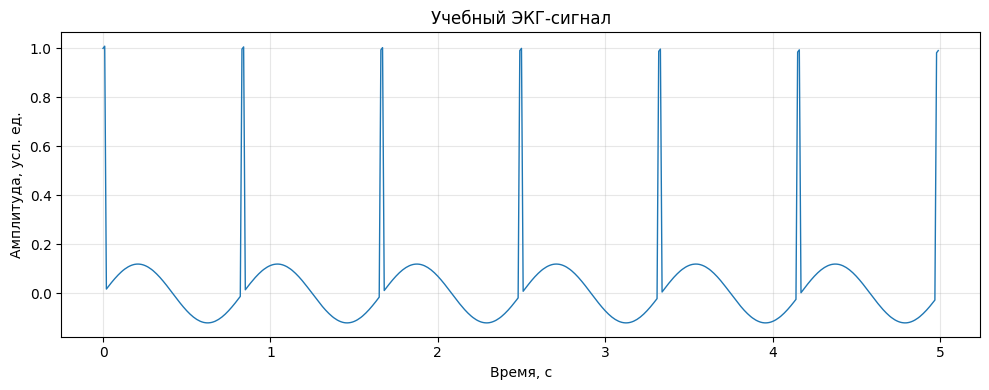

Мини-вывод: оцените регулярность пиков, амплитуду и наличие шума.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Задание: визуализировать учебный ЭКГ-сигнал и описать его особенности.
# Что сделать студенту: выберите один из файлов data/ecg/ecg_sample_*.csv, постройте график,
# отметьте регулярность ритма и наличие шума/изменений формы сигнала.

file_path = "/content/ecg/ecg_sample_1_norm.csv"
data = pd.read_csv(file_path)

plt.figure(figsize=(10, 4))
plt.plot(data["time_sec"], data["signal"], linewidth=1)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, усл. ед.")
plt.title("Учебный ЭКГ-сигнал")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Мини-вывод: оцените регулярность пиков, амплитуду и наличие шума.")

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Задание: обучить простую модель классификации по готовым признакам ЭКГ.
# Что сделать студенту: запустите код, изучите sensitivity/recall, specificity, precision, F1 и ROC-AUC.
# Сделайте вывод, почему accuracy недостаточна для медицинских задач.

data = pd.read_csv("/content/ecg/ecg_features_50.csv")
X = data.drop(columns=["sample_id", "label"])
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Classification report:")
print(classification_report(y_test, y_pred, target_names=["норма", "патология/аритмия"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 3))

Confusion matrix:
[[8 0]
 [0 7]]
Classification report:
                   precision    recall  f1-score   support

            норма       1.00      1.00      1.00         8
патология/аритмия       1.00      1.00      1.00         7

         accuracy                           1.00        15
        macro avg       1.00      1.00      1.00        15
     weighted avg       1.00      1.00      1.00        15

ROC-AUC: 1.0


Dice: 0.822
IoU: 0.698


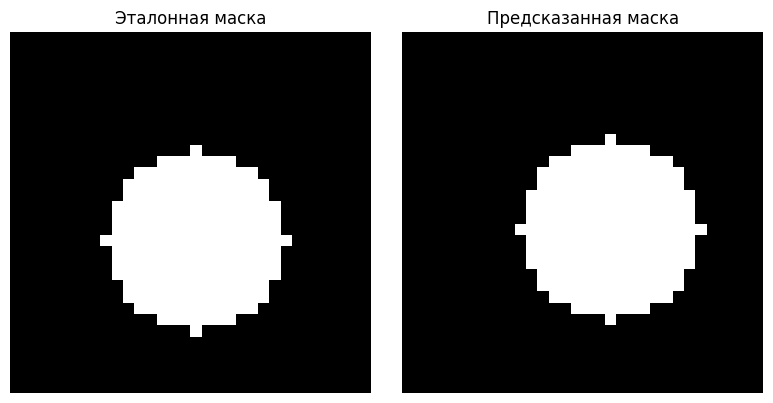

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Задание: рассчитать Dice coefficient и IoU для эталонной и предсказанной масок.
# Что сделать студенту: выберите пару файлов mask_true_N.csv и mask_pred_N.csv,
# рассчитайте метрики, визуализируйте маски и объясните медицинский смысл несовпадения.

true = pd.read_csv("/content/segmentation/mask_true_1.csv", header=None).values
pred = pd.read_csv("/content/segmentation/mask_pred_1.csv", header=None).values

intersection = np.logical_and(true == 1, pred == 1).sum()
dice = 2 * intersection / ((true == 1).sum() + (pred == 1).sum())
iou = intersection / np.logical_or(true == 1, pred == 1).sum()

print("Dice:", round(dice, 3))
print("IoU:", round(iou, 3))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(true, cmap="gray"); axes[0].set_title("Эталонная маска")
axes[1].imshow(pred, cmap="gray"); axes[1].set_title("Предсказанная маска")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

In [4]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Задание: реализовать минимальный retrieval-поиск по синтетическим фрагментам ЭМК/рекомендаций.
# Что сделать студенту: измените вопрос, посмотрите топ-3 найденных фрагмента и объясните,
# как retrieval снижает риск галлюцинаций LLM.

docs = pd.read_csv("/content/nlp/emk_fragments_synthetic.csv")
query = "пациент с одышкой и снижением сатурации"

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(docs["text"])
q = vectorizer.transform([query])
scores = cosine_similarity(q, X).ravel()

docs["score"] = scores
print(docs.sort_values("score", ascending=False).head(3)[["doc_id", "text", "score"]])

   doc_id                                               text     score
3  doc_04  Пациент получает несколько лекарственных препа...  0.247212
0  doc_01  Пациент предъявляет жалобы на одышку при нагру...  0.225944
1  doc_02  На ЭКГ отмечается нерегулярный ритм; требуется...  0.000000


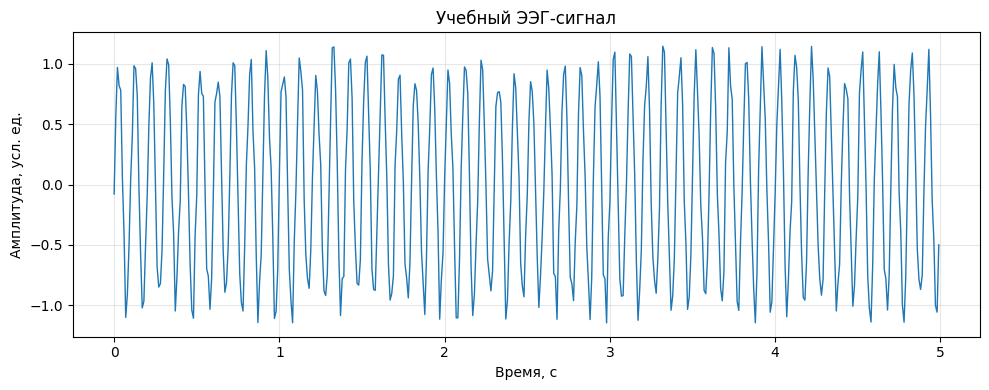

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Дополнительное задание: визуализация учебного ЭЭГ-сигнала.
# Студент должен построить график и приблизительно описать частотный характер сигнала.

data = pd.read_csv("/content/eeg/eeg_sample_1_alpha.csv")

plt.figure(figsize=(10, 4))
plt.plot(data["time_sec"], data["signal"], linewidth=1)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, усл. ед.")
plt.title("Учебный ЭЭГ-сигнал")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()